# Paso 4 — Construcción de Medidas Estadísticas Descriptivas
**Análisis completo: distribuciones, correlaciones, tendencias temporales y geográficas**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import os, warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11

BASE_DIR  = os.path.abspath('..')
PROCESSED = os.path.join(BASE_DIR, 'dataset', 'processed')
FIGURES   = os.path.join(BASE_DIR, 'docs', 'figures')

df = pd.read_csv(os.path.join(PROCESSED, 'dataset_procesado.csv'))
PARAMS  = ['pH', 'Turbidez', 'Temperatura']
PALETA  = {'Optima': '#2ECC71', 'Alerta': '#F39C12', 'Contaminada': '#E74C3C'}
ORDEN   = ['Optima', 'Alerta', 'Contaminada']

print(f'Dataset cargado: {df.shape[0]:,} muestras')
df[PARAMS + ['ETIQUETA']].head()

Dataset cargado: 6,058 muestras


,pH,Turbidez,Temperatura,ETIQUETA
0,6.96,5.0,13.2,Optima
1,6.78,25.0,17.6,Contaminada
2,10.08,28.0,14.5,Contaminada
3,7.06,42.0,19.2,Contaminada
4,7.76,33.0,19.0,Contaminada


## 4.1 — Estadísticas descriptivas globales

In [2]:
desc = df[PARAMS].describe(percentiles=[.10, .25, .50, .75, .90]).T
desc['cv%']   = (desc['std'] / desc['mean'] * 100).round(2)
desc['rango'] = (desc['max'] - desc['min']).round(3)
desc['IQR']   = (desc['75%'] - desc['25%']).round(3)
print('=== Estadísticas descriptivas globales ===')
desc.round(4)

=== Estadísticas descriptivas globales ===


,count,mean,std,min,10%,25%,50%,75%,90%,max,cv%,rango,IQR
pH,6058.0,7.2083,0.7126,4.08,6.307,6.78,7.265,7.71,8.04,10.08,9.89,6.0,0.93
Turbidez,6058.0,128.2757,167.6566,0.80,5.000,16.00,55.000,180.00,370.00,820.00,130.70,819.2,164.00
Temperatura,6058.0,23.0298,4.9088,2.50,16.400,19.50,23.500,26.80,29.20,38.20,21.32,35.7,7.30


In [3]:
# Estadísticas por clase
print('=== Estadísticas por clase de calidad ===')
df.groupby('ETIQUETA')[PARAMS].agg(['mean', 'std', 'min', 'max']).round(3)

=== Estadísticas por clase de calidad ===


pH                     Turbidez                       \
              mean    std   min    max     mean      std  min    max   
ETIQUETA                                                               
Alerta       7.417  0.701  6.00   8.91    6.489    2.430  1.1   10.0   
Contaminada  7.149  0.712  4.08  10.08  154.243  173.676  0.8  820.0   
Optima       7.599  0.525  6.50   8.48    2.988    1.006  0.8    5.0   

            Temperatura                     
                   mean    std   min   max  
ETIQUETA                                    
Alerta           21.122  5.119   6.8  30.0  
Contaminada      23.677  4.657   2.5  38.2  
Optima           18.118  3.926  10.1  25.0

## 4.2 — Histogramas con curva KDE por clase

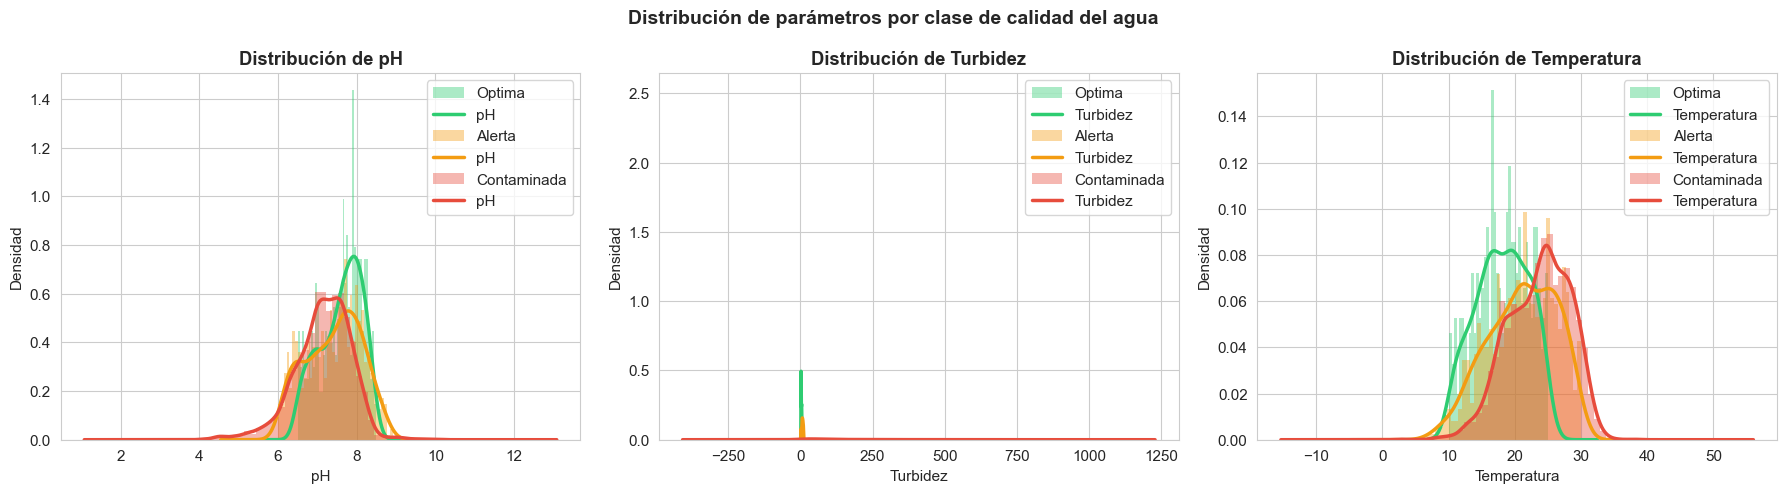

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, param in zip(axes, PARAMS):
    for etiqueta in ORDEN:
        subset = df[df['ETIQUETA'] == etiqueta][param].dropna()
        ax.hist(subset, bins=40, alpha=0.4, color=PALETA[etiqueta],
                label=etiqueta, density=True, edgecolor='none')
        if len(subset) > 5:
            subset.plot.kde(ax=ax, color=PALETA[etiqueta], linewidth=2.5)
    ax.set_title(f'Distribución de {param}', fontweight='bold')
    ax.set_xlabel(param)
    ax.set_ylabel('Densidad')
    ax.legend()

plt.suptitle('Distribución de parámetros por clase de calidad del agua', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '03_histogramas_kde.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4.3 — Boxplots por clase

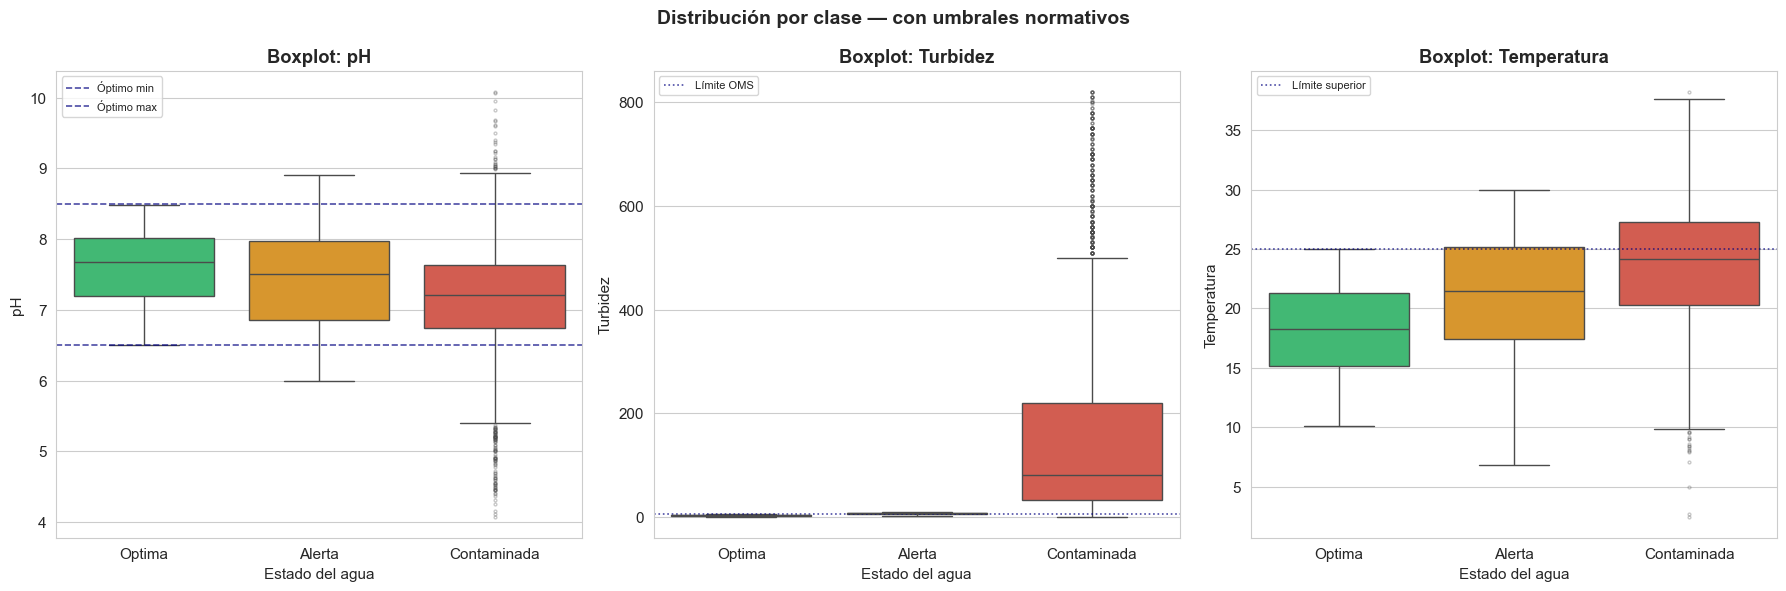

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, param in zip(axes, PARAMS):
    sns.boxplot(
        data=df, x='ETIQUETA', y=param, order=ORDEN,
        palette=PALETA, ax=ax,
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    # Líneas de referencia normativa
    refs = {'pH': [(6.5, 'Óptimo min', '--'), (8.5, 'Óptimo max', '--')],
            'Turbidez': [(5.0, 'Límite OMS', ':')],
            'Temperatura': [(25.0, 'Límite superior', ':')]}
    for val, label, ls in refs.get(param, []):
        ax.axhline(val, color='navy', linestyle=ls, linewidth=1.2, alpha=0.7, label=label)
    ax.set_title(f'Boxplot: {param}', fontweight='bold')
    ax.set_xlabel('Estado del agua')
    ax.legend(fontsize=8)

plt.suptitle('Distribución por clase — con umbrales normativos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '03_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4.4 — Matriz de correlación

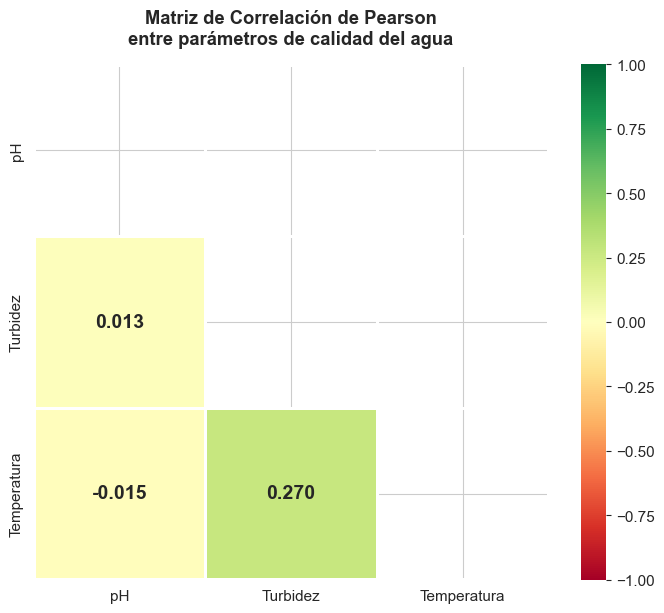


Interpretación:
  pH vs Turbidez: r = 0.013 → correlación débil positiva
  pH vs Temperatura: r = -0.015 → correlación débil negativa
  Turbidez vs Temperatura: r = 0.270 → correlación débil positiva


In [6]:
corr = df[PARAMS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, mask=mask, ax=ax,
            linewidths=1, square=True, annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Matriz de Correlación de Pearson\nentre parámetros de calidad del agua',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '03_correlacion.png'), dpi=150)
plt.show()

print('\nInterpretación:')
for i in range(len(PARAMS)):
    for j in range(i+1, len(PARAMS)):
        r = corr.iloc[i, j]
        fuerza    = 'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'
        direccion = 'positiva' if r > 0 else 'negativa'
        print(f'  {PARAMS[i]} vs {PARAMS[j]}: r = {r:.3f} → correlación {fuerza} {direccion}')

## 4.5 — Scatter plots (pairplot)

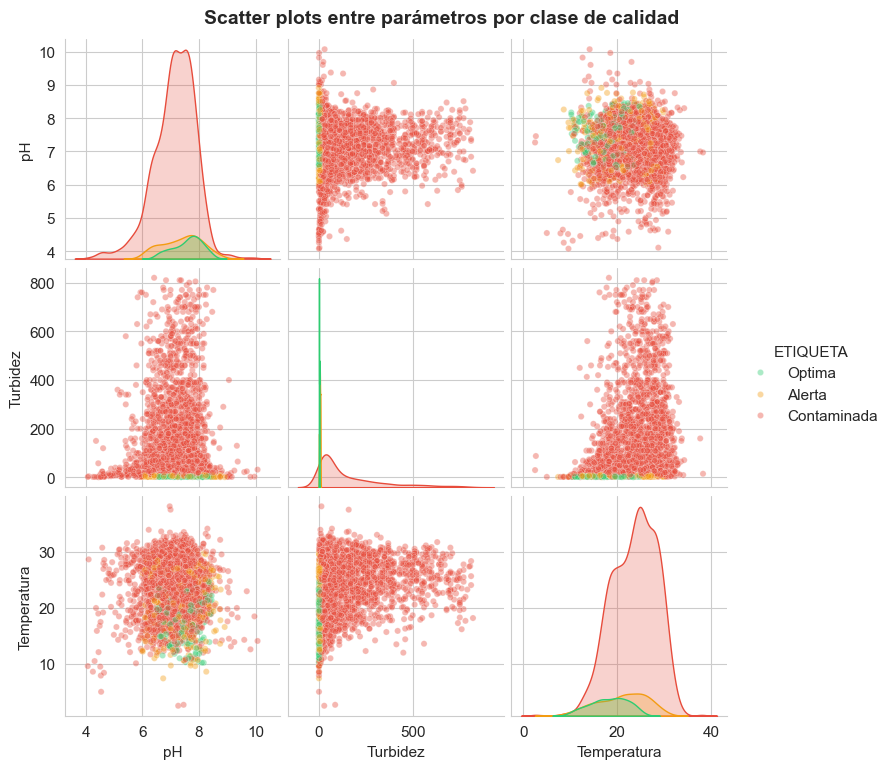

In [7]:
g = sns.pairplot(
    df[PARAMS + ['ETIQUETA']].sample(min(3000, len(df)), random_state=42),
    hue='ETIQUETA', palette=PALETA,
    hue_order=ORDEN, diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20},
    diag_kws={'fill': True}
)
g.fig.suptitle('Scatter plots entre parámetros por clase de calidad',
               y=1.02, fontsize=14, fontweight='bold')
plt.savefig(os.path.join(FIGURES, '03_pairplot.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4.6 — Análisis temporal (evolución anual)

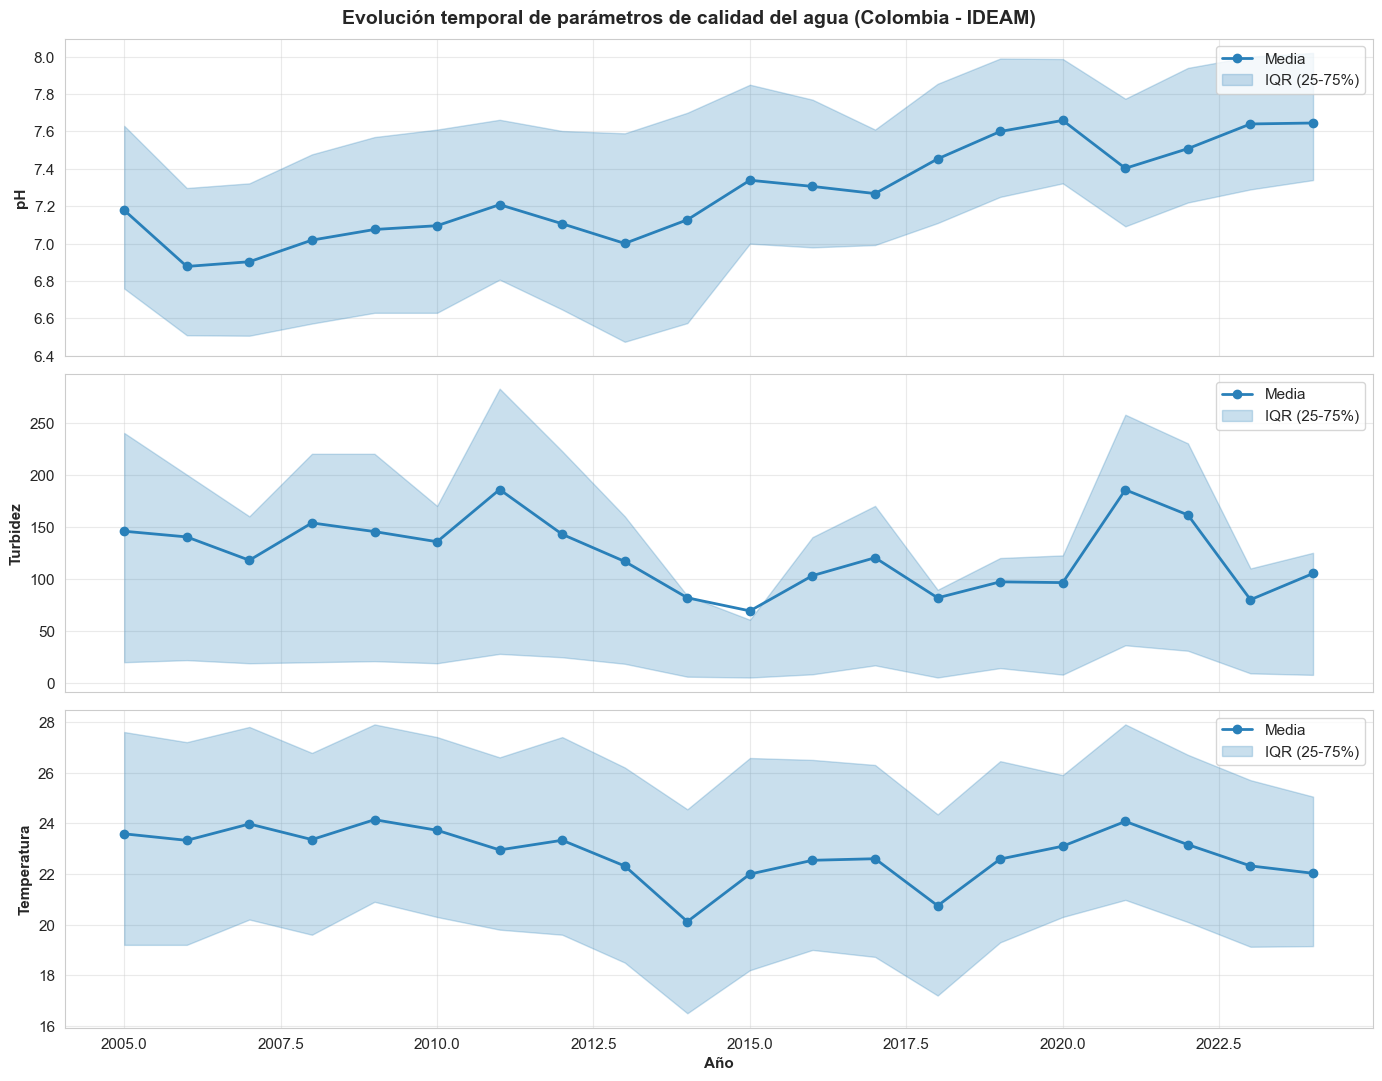

In [8]:
if 'AÑO' in df.columns and df['AÑO'].notna().sum() > 0:
    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
    for ax, param in zip(axes, PARAMS):
        anual = df.groupby('AÑO')[param].agg(['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
        anual.columns = ['media', 'q25', 'q75']
        ax.plot(anual.index, anual['media'], 'o-', linewidth=2, color='#2980B9', label='Media')
        ax.fill_between(anual.index, anual['q25'], anual['q75'],
                        alpha=0.25, color='#2980B9', label='IQR (25-75%)')
        ax.set_ylabel(param, fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.4)

    axes[-1].set_xlabel('Año', fontweight='bold')
    plt.suptitle('Evolución temporal de parámetros de calidad del agua (Colombia - IDEAM)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, '03_evolucion_temporal.png'), dpi=150)
    plt.show()
else:
    print('No hay columna AÑO disponible para análisis temporal.')

## 4.7 — Pruebas de normalidad

=== Prueba de Shapiro-Wilk (muestra n=500) ===
  pH          : W=0.9628, p=0.000000 → Normal: No
  Turbidez    : W=0.7454, p=0.000000 → Normal: No
  Temperatura : W=0.9864, p=0.000130 → Normal: No


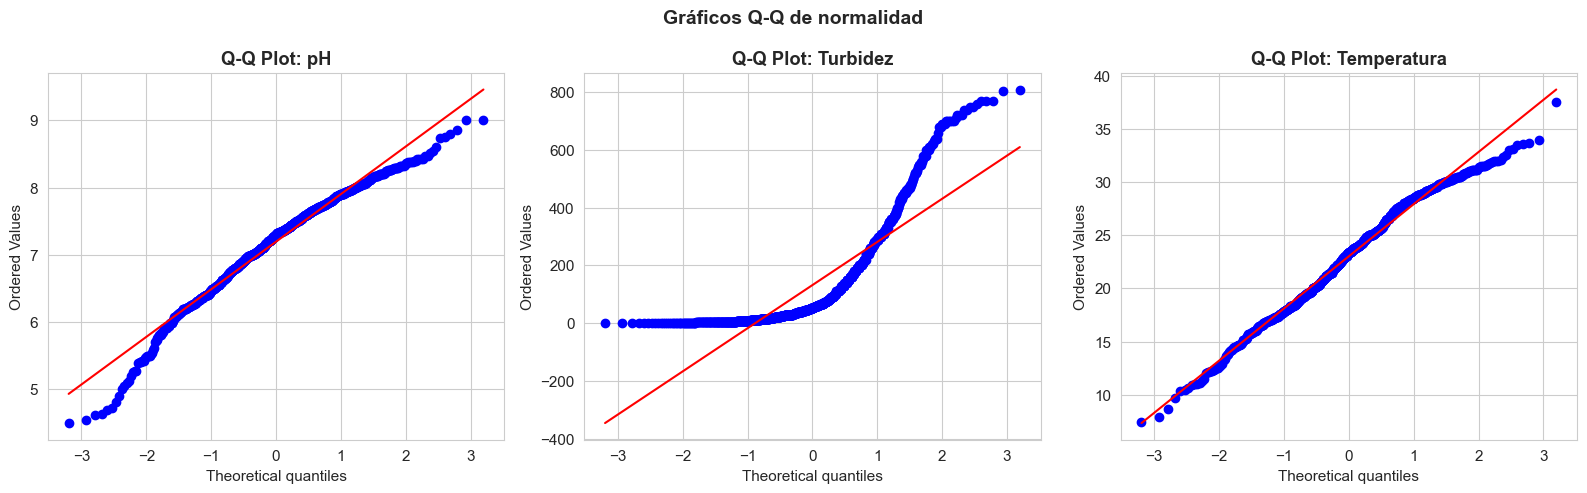

In [9]:
print('=== Prueba de Shapiro-Wilk (muestra n=500) ===')
muestra = df[PARAMS].dropna().sample(min(500, len(df)), random_state=42)
for param in PARAMS:
    stat, p = stats.shapiro(muestra[param].dropna())
    normal  = 'Sí' if p > 0.05 else 'No'
    print(f'  {param:12s}: W={stat:.4f}, p={p:.6f} → Normal: {normal}')

# Q-Q plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, param in zip(axes, PARAMS):
    datos = df[param].dropna().sample(min(1000, df[param].notna().sum()), random_state=42)
    stats.probplot(datos, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {param}', fontweight='bold')

plt.suptitle('Gráficos Q-Q de normalidad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '03_qq_plots.png'), dpi=150)
plt.show()

## 4.8 — Top departamentos y análisis geográfico

Top 15 departamentos (calidad del agua):
                    muestras  pH_media  Turbidez_media  Temp_media  pct_contaminada
DEPARTAMENTO                                                                       
HUILA                   1163      7.60           93.71       21.87             73.9
CUNDINAMARCA            1079      7.12          124.57       20.89             84.6
NARIÑO                   432      7.25           65.31       18.81             56.2
TOLIMA                   431      7.34          148.25       24.31             89.6
BOYACÁ                   401      7.12           76.23       17.96             77.6
SANTANDER                395      7.51          207.45       24.39             94.9
BOLÍVAR                  228      7.04          257.33       29.65             99.1
ANTIOQUIA                225      7.10          159.97       24.19             88.9
META                     212      6.87          189.79       25.84             96.7
MAGDALENA                169      7

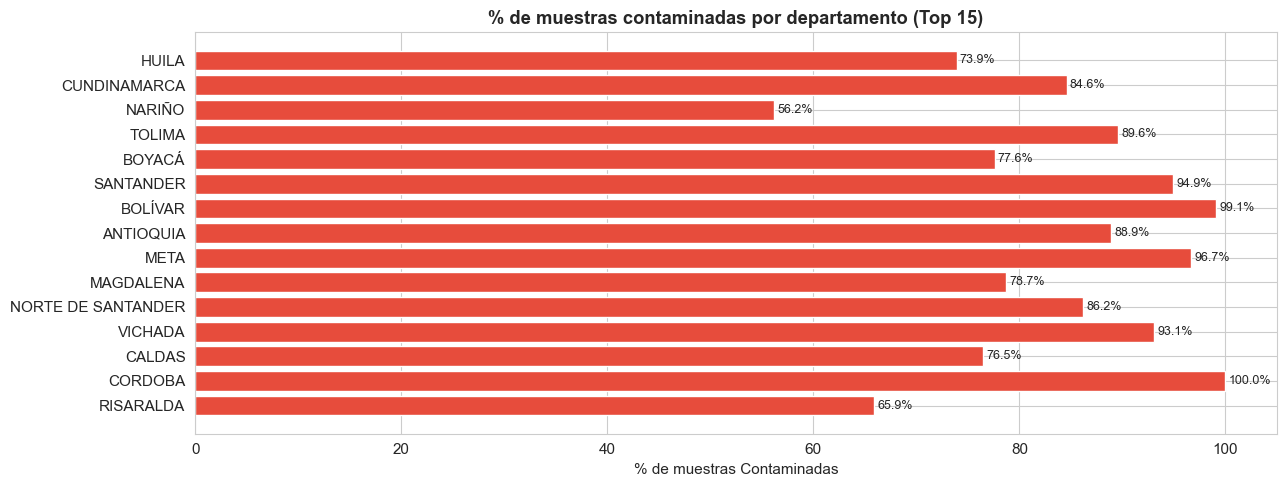

In [10]:
if 'DEPARTAMENTO' in df.columns:
    geo = df.groupby('DEPARTAMENTO').agg(
        muestras        = ('pH', 'count'),
        pH_media        = ('pH', 'mean'),
        Turbidez_media  = ('Turbidez', 'mean'),
        Temp_media      = ('Temperatura', 'mean'),
        pct_contaminada = ('ETIQUETA', lambda x: round((x == 'Contaminada').mean() * 100, 1))
    ).sort_values('muestras', ascending=False).head(15)

    print('Top 15 departamentos (calidad del agua):')
    print(geo.round(2).to_string())

    fig, ax = plt.subplots(figsize=(13, 5))
    colors  = ['#E74C3C' if p > 20 else '#F39C12' if p > 10 else '#2ECC71'
               for p in geo['pct_contaminada']]
    bars = ax.barh(geo.index[::-1], geo['pct_contaminada'][::-1], color=colors[::-1])
    ax.set_xlabel('% de muestras Contaminadas')
    ax.set_title('% de muestras contaminadas por departamento (Top 15)', fontweight='bold')
    for bar in bars:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, '03_contaminacion_departamentos.png'), dpi=150)
    plt.show()